Processing dataset1 - tspcRoundRobin2 with 10 files.
Processing dataset1 - tspcLoadBal2 with 10 files.
Processing dataset1 - tspcKmean2 with 10 files.
Processing dataset1 - tspcRightAsc2 with 10 files.
Processing dataset1 - tspcKMeanEarlySetting2 with 10 files.
Processing dataset1 - tspcRoundRobin3 with 10 files.
Processing dataset1 - tspcLoadBal3 with 10 files.
Processing dataset1 - tspcKmean3 with 10 files.
Processing dataset1 - tspcRightAsc3 with 10 files.
Processing dataset1 - tspcKMeanEarlySetting3 with 10 files.
Processing dataset1 - tspcRoundRobin4 with 10 files.
Processing dataset1 - tspcLoadBal4 with 10 files.
Processing dataset1 - tspcKmean4 with 10 files.
Processing dataset1 - tspcRightAsc4 with 10 files.
Processing dataset1 - tspcKMeanEarlySetting4 with 10 files.
Processing dataset1 - tspcRoundRobin5 with 10 files.
Processing dataset1 - tspcLoadBal5 with 10 files.
Processing dataset1 - tspcKmean5 with 10 files.
Processing dataset1 - tspcRightAsc5 with 10 files.
Processing d

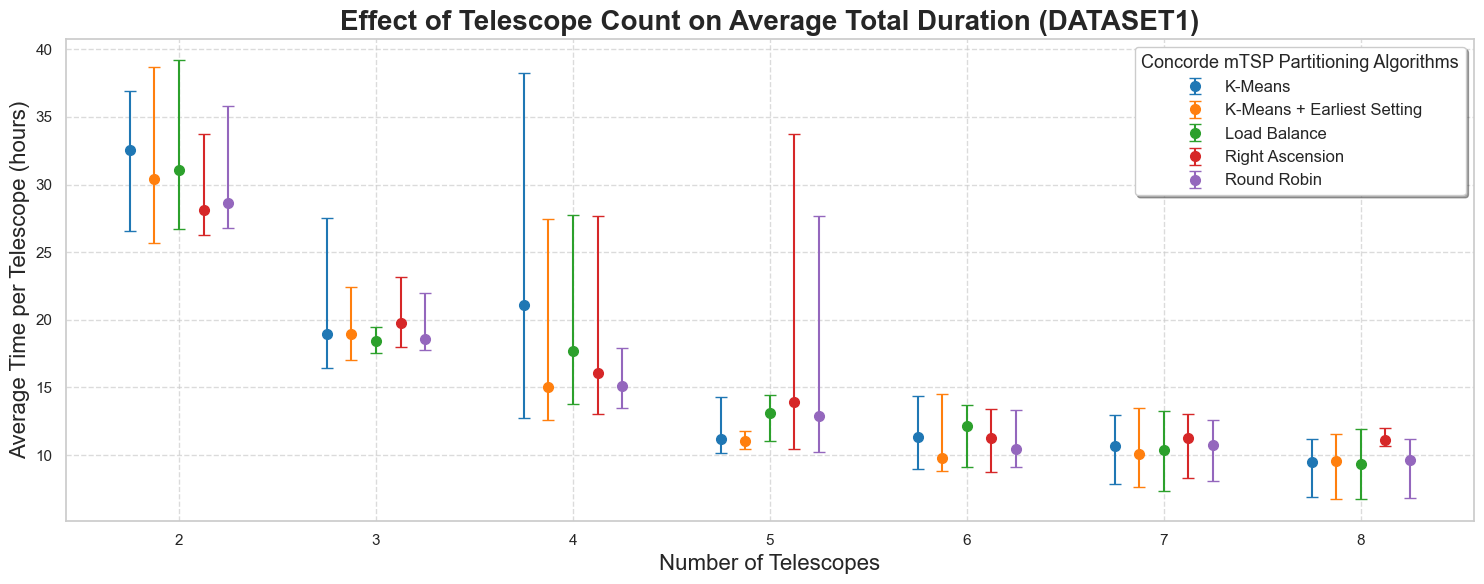

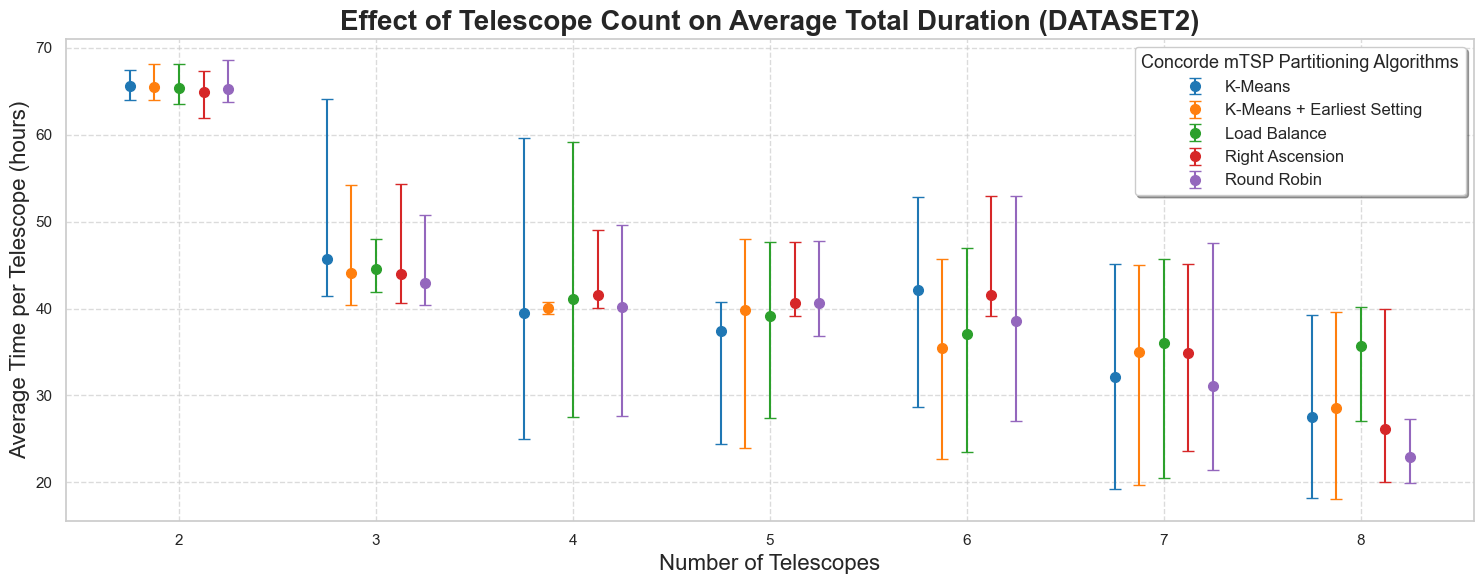

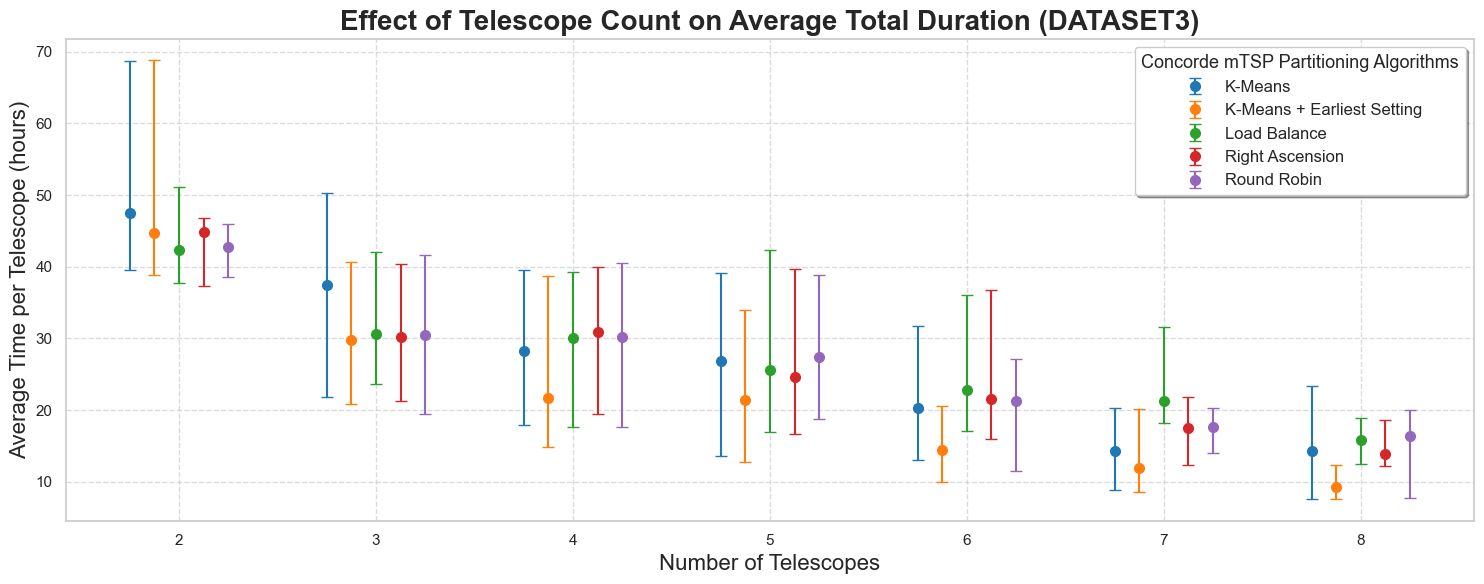

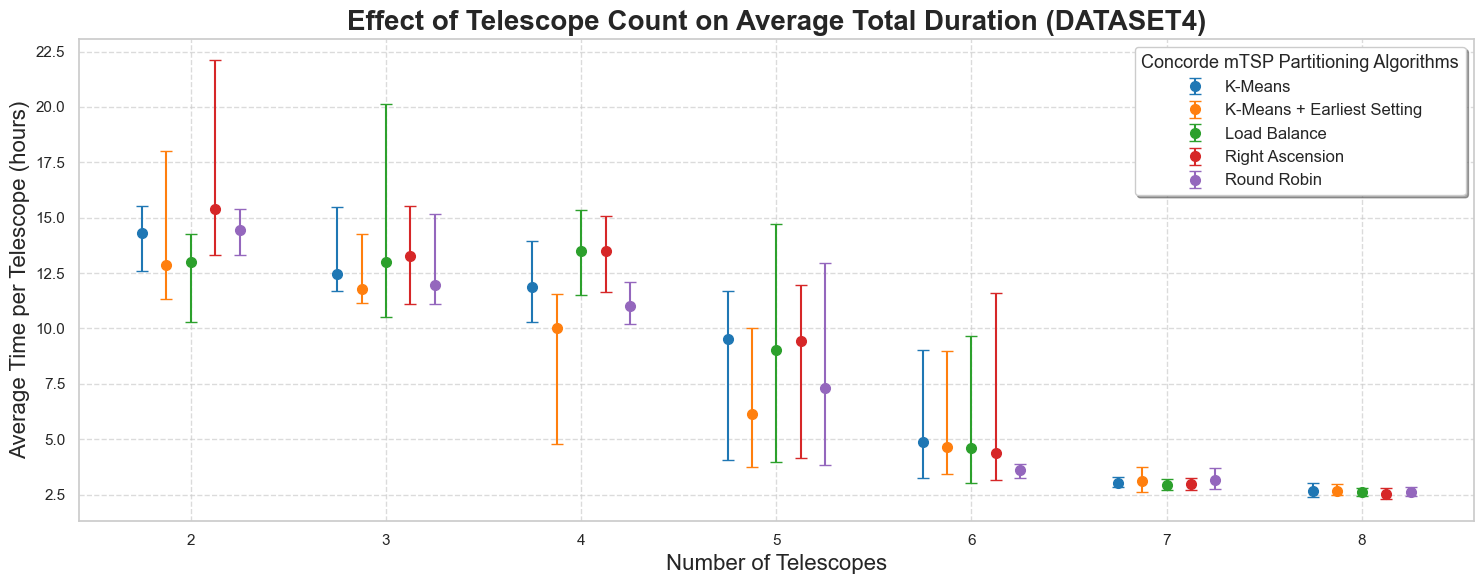

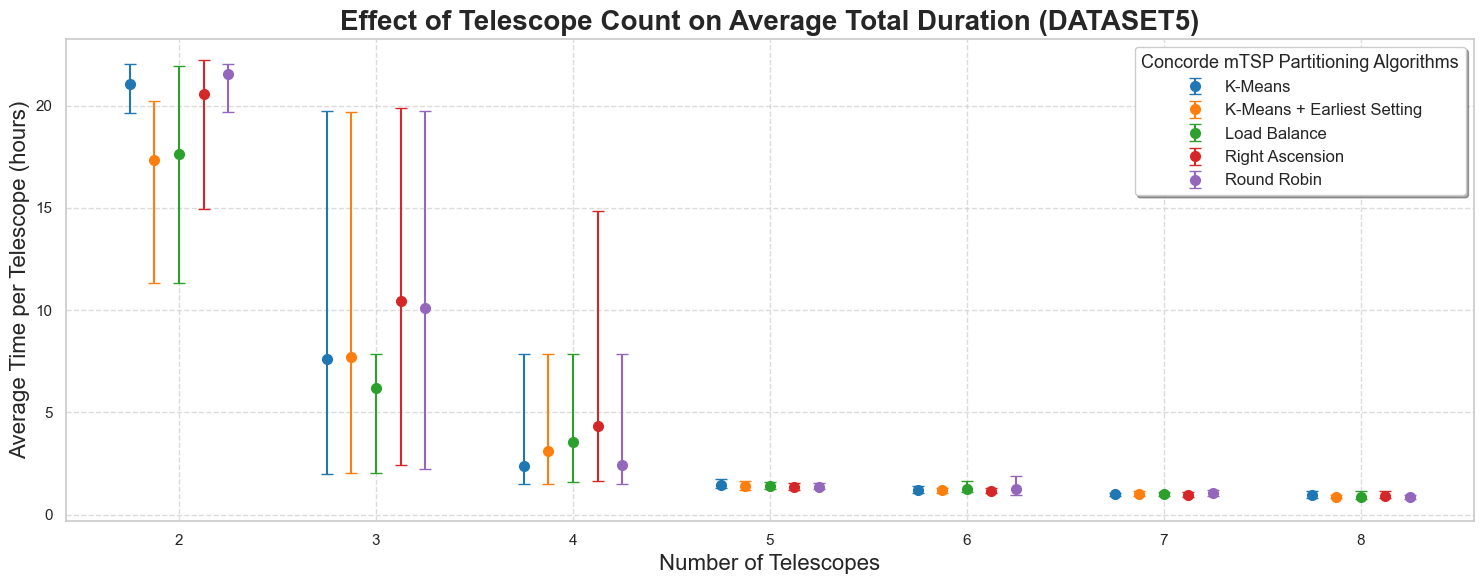

In [25]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re

# Config
%matplotlib inline
sns.set_theme(style="whitegrid", palette="pastel")

# Datasets
datasets = [
    'dataset1/',
    'dataset2/',
    'dataset3/',
    'dataset4/',
    'dataset5/'
]

folder_name_map = {
    "EarliestSetting": "Earliest Setting",
    "Random": "Random",
    "ShortestSlew": "Shortest Slew",
    "tsp": "MTSP Gurobi",
    "tspcRoundRobin": "Round Robin",
    "tspcLoadBal": "Load Balance",
    "tspcKmean": "K-Means",
    "tspcRightAsc": "Right Ascension",
    "tspcKMeanEarlySetting": "K-Means + Earliest Setting"
}

# Automatically detect folders for 2–8 telescopes
all_folders = []
for tele in range(2, 9):
    all_folders += [
        f'tspcRoundRobin{tele}',
        f'tspcLoadBal{tele}',
        f'tspcKmean{tele}',
        f'tspcRightAsc{tele}',
        f'tspcKMeanEarlySetting{tele}'
    ]
folders = all_folders

dataset_dfs = {}

for dataset in datasets:
    dataset_name = os.path.basename(os.path.normpath(dataset)) or dataset.strip('/')

    stats_list = []

    for folder in folders:
        folder_path = os.path.join(dataset, folder)
        csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

        raw_folder_name = os.path.basename(os.path.normpath(folder))
        folder_name = folder_name_map.get(raw_folder_name, raw_folder_name)

        print(f"Processing {dataset_name} - {folder_name} with {len(csv_files)} files.")

        for file in csv_files:
            try:
                df = pd.read_csv(file, header=4)
                df.columns = df.columns.str.strip()

                # Compute total duration: sum Duration over all telescopes
                df['No'] = pd.to_numeric(df['No'], errors='coerce')
                total_duration = df['No'].sum()

                df['Wait time'] = pd.to_numeric(df['Wait time'], errors='coerce')
                total_observation = df['Wait time'].sum()

                tele_count = df['No'].nunique() if 'No' in df.columns else 4

                stats_list.append({
                    'File': os.path.basename(file),
                    'Folder': folder_name,
                    'Telescopes': tele_count,
                    'Total Duration': total_duration / tele_count,
                    'Observation Time': total_observation / tele_count
                })

            except Exception as e:
                print(f"Error processing {file}: {e}")


    dataset_df = pd.DataFrame(stats_list)
    dataset_dfs[dataset_name] = dataset_df

for dataset_name, df in dataset_dfs.items():
    if df.empty:
        continue

    # Clean algorithm names (remove telescope number)
    df['Algorithm'] = df['Folder'].apply(lambda f: folder_name_map.get(re.sub(r'\d+$','', f), f))

    # Aggregate stats
    grouped = (
        df.groupby(['Algorithm', 'Telescopes'])['Total Duration']
        .agg(['mean', 'min', 'max'])
        .reset_index()
    )

    plt.figure(figsize=(15, 6))

    algorithms = grouped['Algorithm'].unique()
    palette = sns.color_palette("tab10", n_colors=len(algorithms))
    color_map = dict(zip(algorithms, palette))

    telescope_counts = sorted(grouped['Telescopes'].unique())
    num_algos = len(algorithms)

    # Precompute horizontal offsets like your example
    # Spread them evenly around each integer telescope count
    offset_values = np.linspace(-0.25, 0.25, num_algos)

    for i, algo in enumerate(algorithms):
        algo_data = grouped[grouped['Algorithm'] == algo]
        # Compute x-values with fixed offsets
        x = algo_data['Telescopes'] + offset_values[i]
        y = algo_data['mean'].values
        yerr = np.array([
            y - algo_data['min'].values,
            algo_data['max'].values - y
        ])

        plt.errorbar(
            x, y, yerr=yerr,
            fmt='o', capsize=4, markersize=7,
            color=color_map[algo],
            label=algo
        )

    plt.title(f"Effect of Telescope Count on Average Total Duration ({dataset_name.upper()})", fontsize=20, weight='bold')
    plt.xlabel("Number of Telescopes", fontsize=16)
    plt.ylabel("Average Time per Telescope (hours)", fontsize=16)
    plt.xticks(telescope_counts)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(
        title="Concorde mTSP Partitioning Algorithms",
        loc='upper right',       # position inside the axes
        fontsize=12,
        frameon=True,            # adds a box around legend
        shadow=True,             # optional
        title_fontsize=13)
    plt.tight_layout()
    plt.show()

Processing dataset1 - 10 iterations with 10 files.
Processing dataset1 - 100 iterations with 10 files.
Processing dataset2 - 10 iterations with 10 files.
Processing dataset2 - 100 iterations with 10 files.
Processing dataset3 - 10 iterations with 10 files.
Processing dataset3 - 100 iterations with 10 files.
Processing dataset4 - 10 iterations with 10 files.
Processing dataset4 - 100 iterations with 10 files.
Processing dataset5 - 10 iterations with 10 files.
Processing dataset5 - 100 iterations with 10 files.


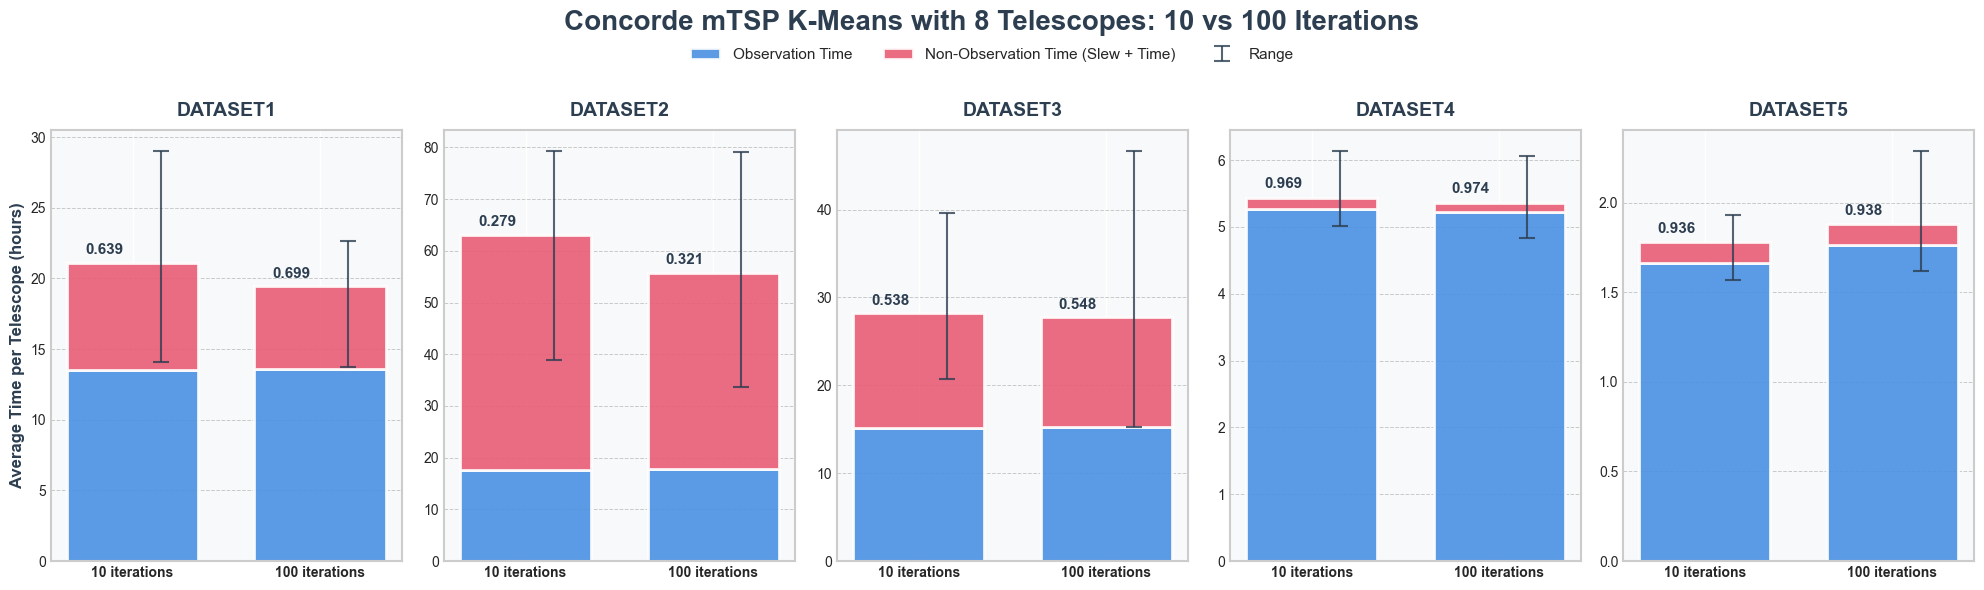

In [21]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Enhanced Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Dataset Configuration
datasets = ['dataset1/', 'dataset2/', 'dataset3/', 'dataset4/', 'dataset5/']
folders = ['tspcKmean8ite10', 'tspcKmean8']
folder_name_map = {
    "tspcKmean8ite10": "10 iterations",
    "tspcKmean8": "100 iterations"
}

# Color palette
colors = {
    'observation': '#4A90E2',
    'non_observation': '#E85D75',
    'error_bar': '#2C3E50'
}

# Data Processing
dataset_dfs = {}

for dataset in datasets:
    dataset_name = os.path.basename(os.path.normpath(dataset)) or dataset.strip('/')
    stats_list = []
    
    for folder in folders:
        folder_path = os.path.join(dataset, folder)
        csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
        raw_folder_name = os.path.basename(os.path.normpath(folder))
        folder_name = folder_name_map.get(raw_folder_name, raw_folder_name)
        
        print(f"Processing {dataset_name} - {folder_name} with {len(csv_files)} files.")
        
        for file in csv_files:
            try:
                df = pd.read_csv(file, header=4)
                df.columns = df.columns.str.strip()
                df['No'] = pd.to_numeric(df['No'], errors='coerce')
                df['Wait time'] = pd.to_numeric(df['Wait time'], errors='coerce')
                
                stats_list.append({
                    'File': os.path.basename(file),
                    'Folder': folder_name,
                    'Total Duration': df['No'].sum() / 4,
                    'Observation Time': df['Wait time'].sum() / 4
                })
            except Exception as e:
                print(f"Error processing {file}: {e}")
    
    dataset_dfs[dataset_name] = pd.DataFrame(stats_list)

# Create unified visualization with subplots
valid_datasets = {k: v for k, v in dataset_dfs.items() if not v.empty}
n_datasets = len(valid_datasets)

if n_datasets == 0:
    print("No valid datasets to display.")
else:
    # Create subplots - 5 datasets in a row
    fig, axes = plt.subplots(1, n_datasets, figsize=(4*n_datasets, 6), dpi=100)
    if n_datasets == 1:
        axes = [axes]
    
    fig.suptitle(f"Concorde mTSP K-Means with 8 Telescopes: 10 vs 100 Iterations", 
                 fontsize=20, weight='bold', y=0.98, color='#2C3E50')
    
    for idx, (dataset_name, df) in enumerate(valid_datasets.items()):
        ax = axes[idx]
        
        # Aggregate statistics
        grouped = df.groupby('Folder').agg({
            'Total Duration': ['mean', 'min', 'max'],
            'Observation Time': ['mean', 'min', 'max']
        })
        grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
        summary = grouped.reset_index()
        summary['Non-Observation Time_mean'] = (summary['Total Duration_mean'] - 
                                                summary['Observation Time_mean'])
        
        # Sort by desired order
        desired_order = ["10 iterations", "100 iterations"]
        summary['Folder'] = pd.Categorical(summary['Folder'], categories=desired_order, ordered=True)
        summary = summary.sort_values('Folder')
        
        x = np.arange(len(summary))
        bar_width = 0.7
        
        # Stacked bars
        ax.bar(x, summary['Observation Time_mean'], 
               label='Observation Time' if idx == 0 else '', 
               color=colors['observation'], 
               edgecolor='white', 
               linewidth=2, 
               width=bar_width,
               alpha=0.9)
        
        ax.bar(x, summary['Non-Observation Time_mean'], 
               bottom=summary['Observation Time_mean'],
               label='Non-Observation Time (Slew + Time)' if idx == 0 else '', 
               color=colors['non_observation'], 
               edgecolor='white', 
               linewidth=2, 
               width=bar_width,
               alpha=0.9)
        
        # Error bars
        total_err_lower = summary['Total Duration_mean'] - summary['Total Duration_min']
        total_err_upper = summary['Total Duration_max'] - summary['Total Duration_mean']
        
        ax.errorbar(x + 0.15, summary['Total Duration_mean'], 
                    yerr=[total_err_lower, total_err_upper],
                    fmt='none', 
                    ecolor=colors['error_bar'], 
                    capsize=6, 
                    capthick=1.5, 
                    linewidth=1.5,
                    alpha=0.8,
                    label='Range' if idx == 0 else '')
        
        # Efficiency ratios
        observation_ratio = summary['Observation Time_mean'] / summary['Total Duration_mean']
        for i, (total, ratio) in enumerate(zip(summary['Total Duration_mean'], observation_ratio)):
            ax.text(i - 0.05, total + 0.02 * total,
                    f"{ratio:.3f}",
                    ha='right', va='bottom', 
                    fontsize=11, 
                    weight='bold',
                    color=colors['error_bar'])
        
        # Styling
        ax.set_title(f"{dataset_name.upper()}", fontsize=14, weight='bold', pad=10, color='#2C3E50')
        ax.set_xticks(x)
        ax.set_xticklabels(summary['Folder'], fontsize=10, weight='bold', rotation=0)
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.4, color='gray')
        ax.set_axisbelow(True)
        
        # Y-label only on first subplot
        if idx == 0:
            ax.set_ylabel("Average Time per Telescope (hours)", fontsize=12, weight='bold', color='#2C3E50')
        
        # Borders
        for spine in ax.spines.values():
            spine.set_edgecolor('#CCCCCC')
            spine.set_linewidth(1.5)
    
    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.94), 
               ncol=3, fontsize=11, framealpha=0.95, edgecolor='gray', 
               fancybox=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

Processing dataset1 - Earliest Setting: 10 files
Processing dataset1 - Random: 10 files
Processing dataset1 - Shortest Slew: 10 files
Processing dataset1 - mTSP Gurobi: 10 files
Processing dataset1 - mTSP Concorde (RRP): 10 files
Processing dataset1 - mTSP Concorde (LBP): 10 files
Processing dataset1 - mTSP Concorde (KmP): 10 files
Processing dataset1 - mTSP Concorde (RAP): 10 files
Processing dataset1 - mTSP Concorde (KmP + ES): 10 files
Processing dataset2 - Earliest Setting: 10 files
Processing dataset2 - Random: 10 files
Processing dataset2 - Shortest Slew: 10 files
Processing dataset2 - mTSP Gurobi: 10 files
Processing dataset2 - mTSP Concorde (RRP): 10 files
Processing dataset2 - mTSP Concorde (LBP): 10 files
Processing dataset2 - mTSP Concorde (KmP): 10 files
Processing dataset2 - mTSP Concorde (RAP): 10 files
Processing dataset2 - mTSP Concorde (KmP + ES): 10 files
Processing dataset3 - Earliest Setting: 10 files
Processing dataset3 - Random: 10 files
Processing dataset3 - Shor

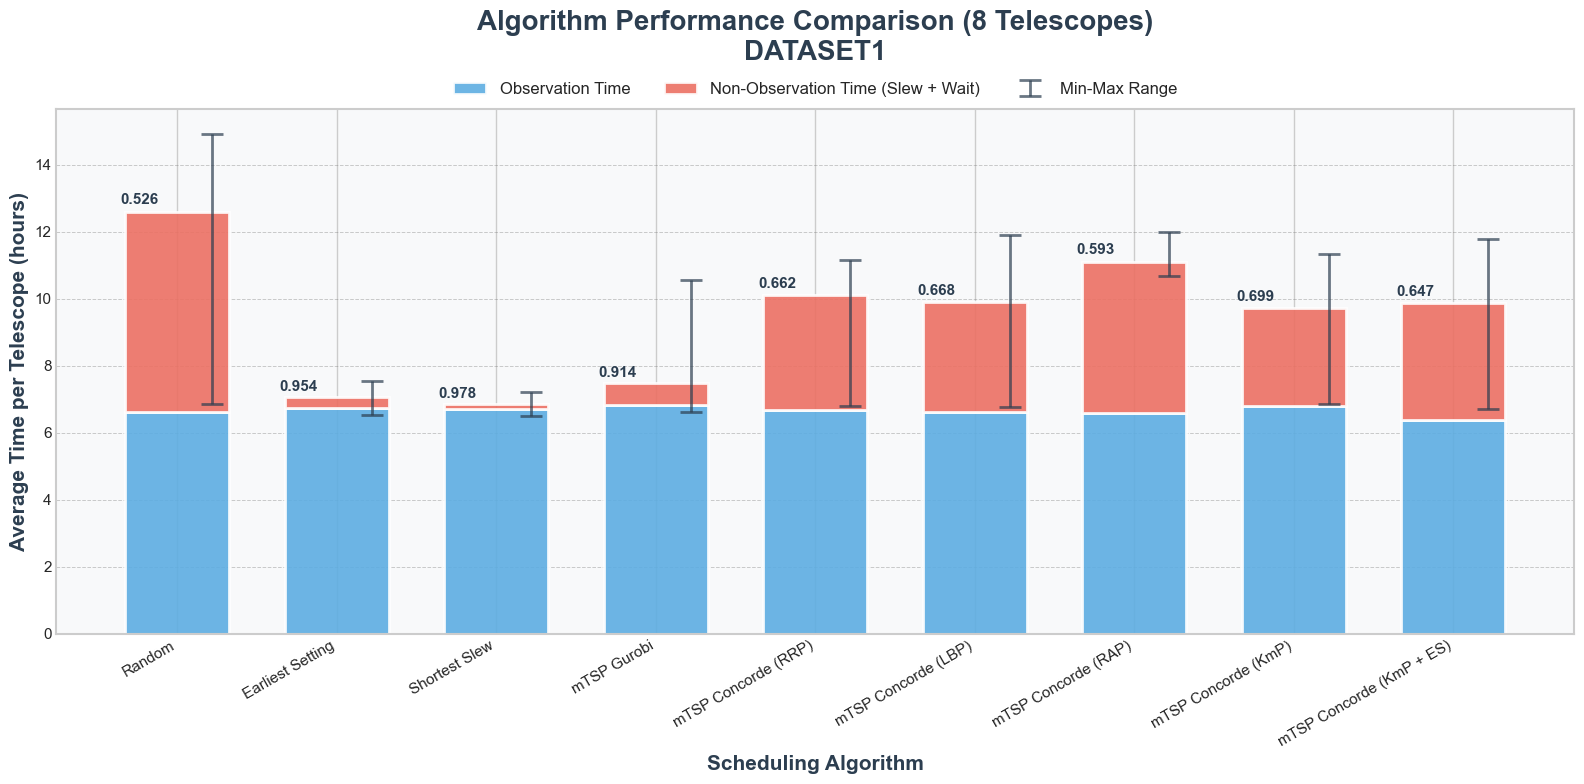

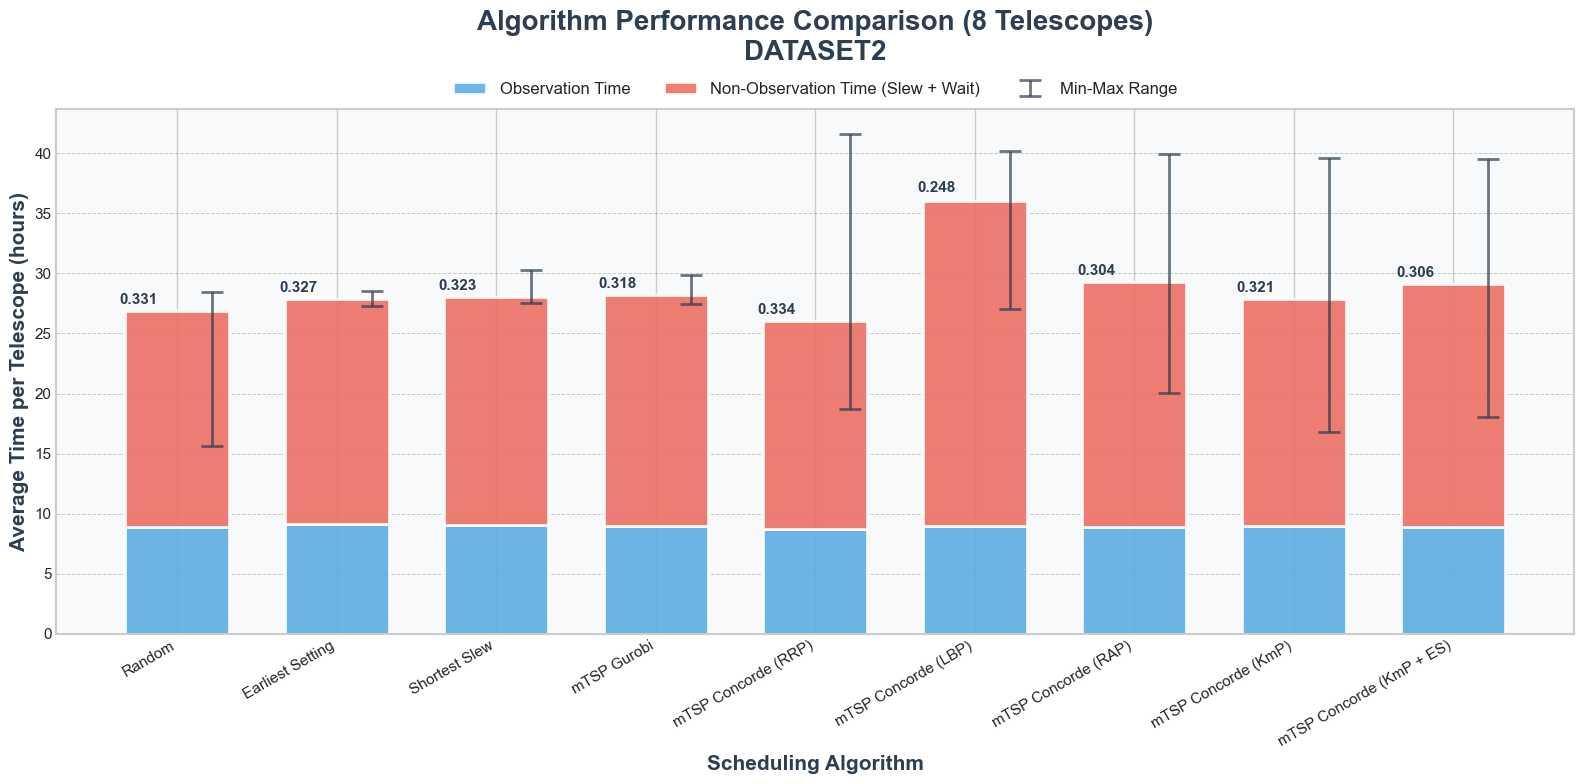

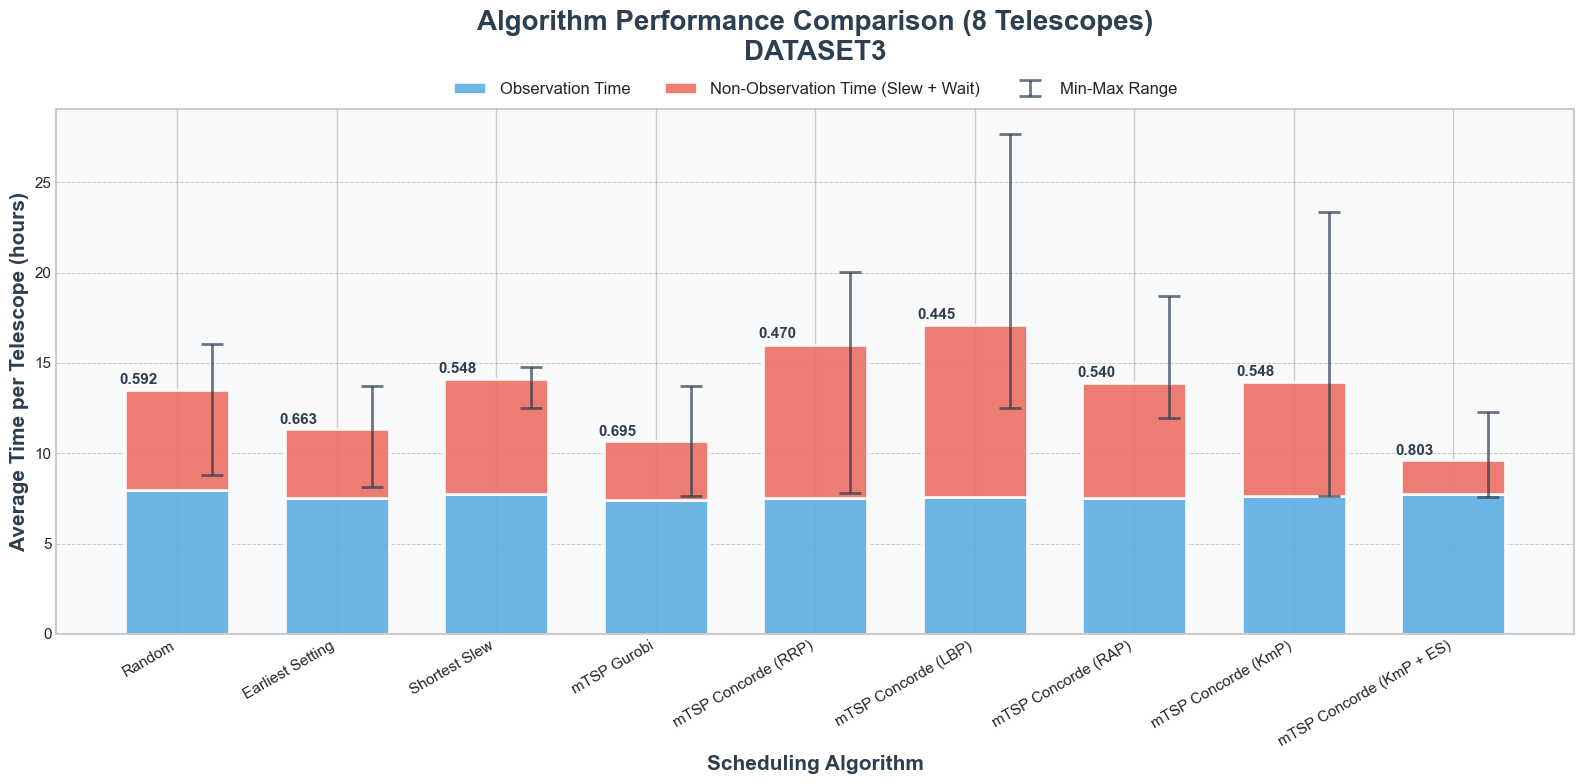

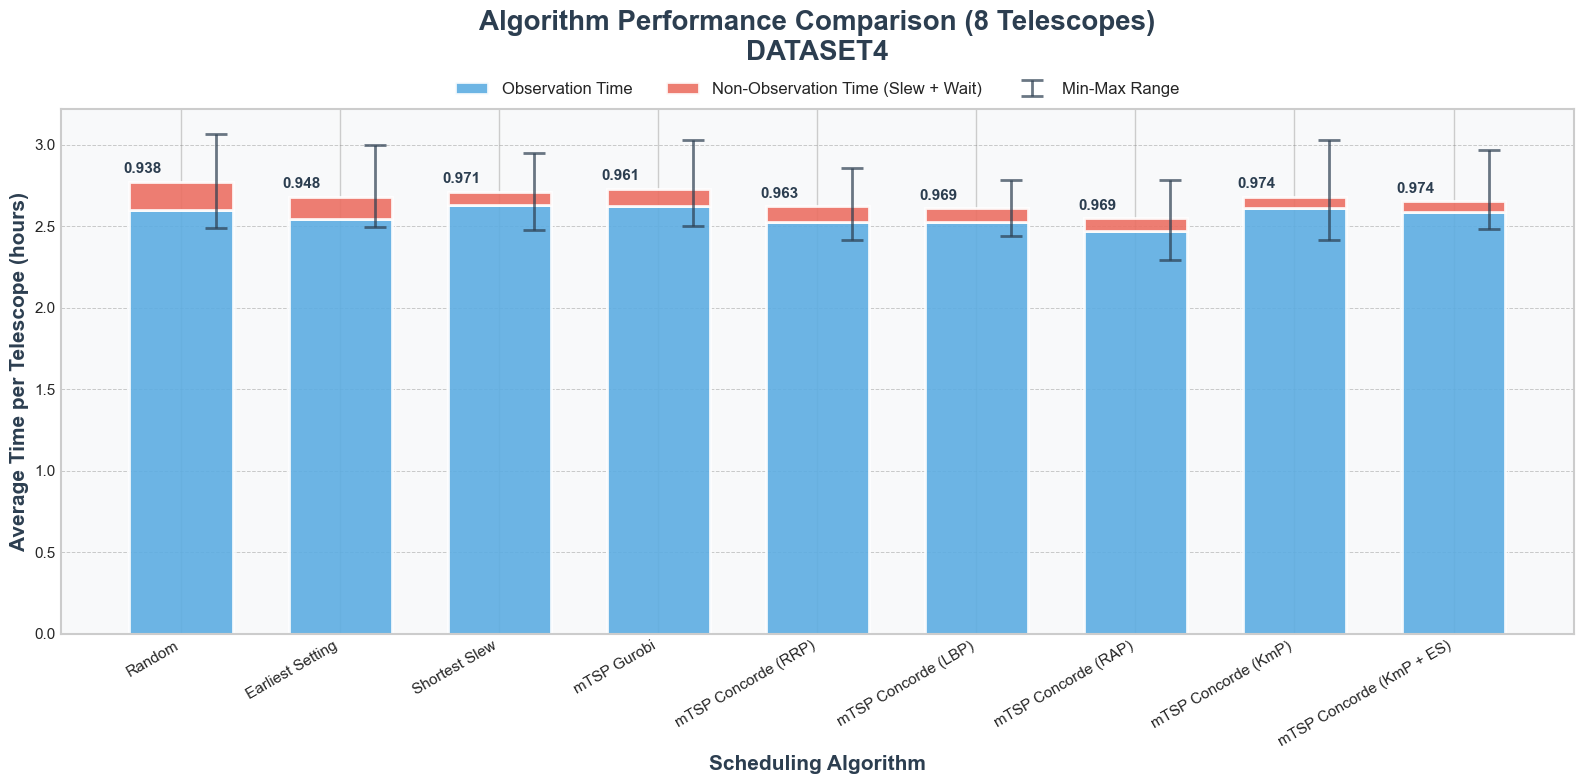

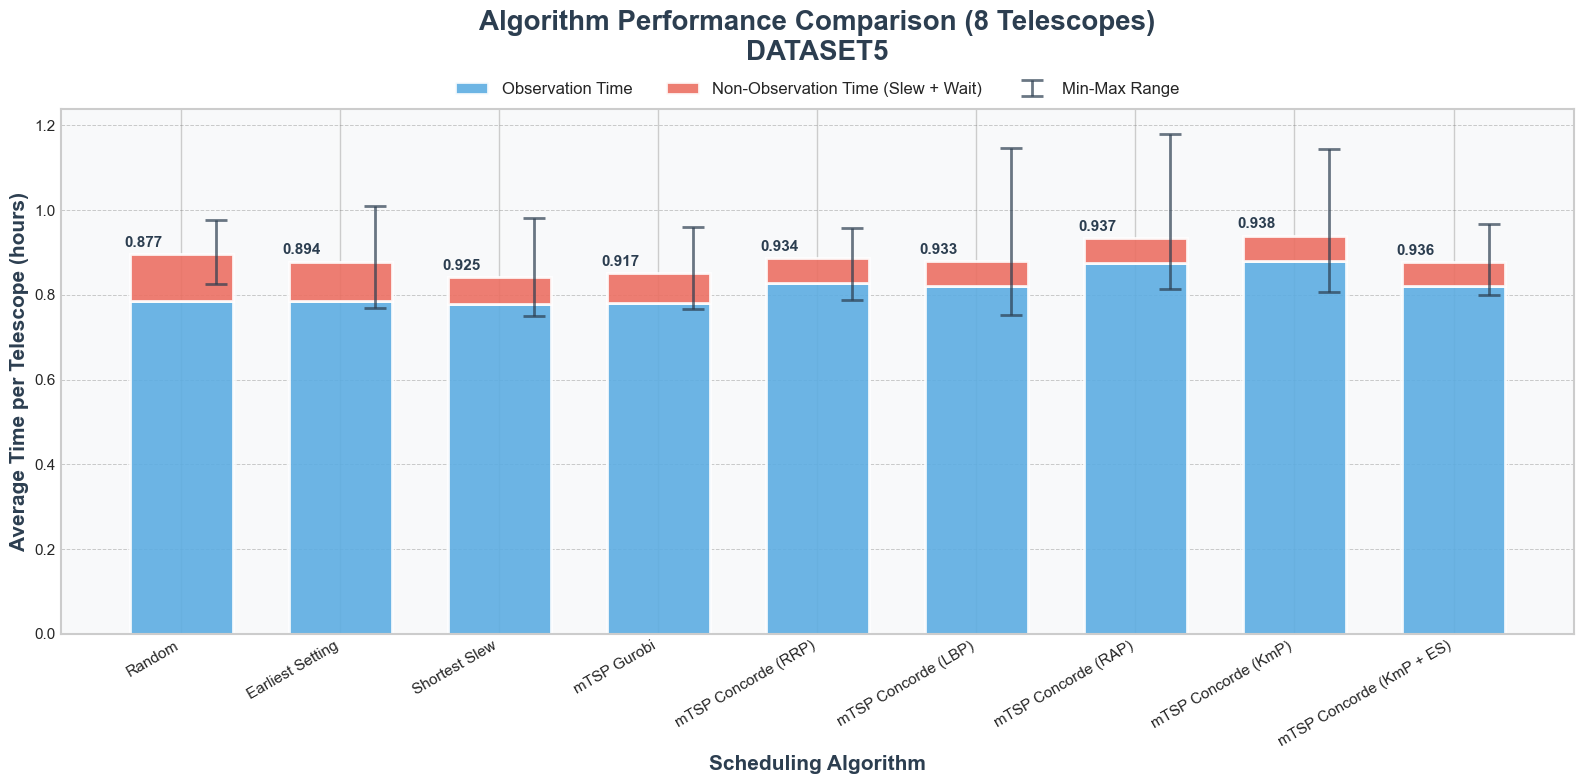

In [26]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Enhanced Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'sans-serif'

# Datasets
datasets = ['dataset1/', 'dataset2/', 'dataset3/', 'dataset4/', 'dataset5/']

# Algorithm folder mappings (8 telescopes only)
folders_8tel = [
    'EarliestSetting8tele',
    'Random8tele',
    'ShortestSlew8tele',
    'tsp8',
    'tspcRoundRobin8',
    'tspcLoadBal8',
    'tspcKmean8',
    'tspcRightAsc8',
    'tspcKMeanEarlySetting8'
]

folder_name_map = {
    "EarliestSetting8tele": "Earliest Setting",
    "Random8tele": "Random",
    "ShortestSlew8tele": "Shortest Slew",
    "tsp8": "mTSP Gurobi",
    "tspcRoundRobin8": "mTSP Concorde (RRP)",
    "tspcLoadBal8": "mTSP Concorde (LBP)",
    "tspcKmean8": "mTSP Concorde (KmP)",
    "tspcRightAsc8": "mTSP Concorde (RAP)",
    "tspcKMeanEarlySetting8": "mTSP Concorde (KmP + ES)"
}

# Data Processing
dataset_dfs = {}

for dataset in datasets:
    dataset_name = os.path.basename(os.path.normpath(dataset)) or dataset.strip('/')
    stats_list = []
    
    for folder in folders_8tel:
        folder_path = os.path.join(dataset, folder)
        csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
        
        if len(csv_files) == 0:
            continue
            
        raw_folder_name = os.path.basename(os.path.normpath(folder))
        folder_name = folder_name_map.get(raw_folder_name, raw_folder_name)
        
        print(f"Processing {dataset_name} - {folder_name}: {len(csv_files)} files")
        
        for file in csv_files:
            try:
                df = pd.read_csv(file, header=4)
                df.columns = df.columns.str.strip()
                df['No'] = pd.to_numeric(df['No'], errors='coerce')
                df['Wait time'] = pd.to_numeric(df['Wait time'], errors='coerce')
                
                total_duration = df['No'].sum() / 8
                observation_time = df['Wait time'].sum() / 8
                
                stats_list.append({
                    'File': os.path.basename(file),
                    'Algorithm': folder_name,
                    'Total Duration': total_duration,
                    'Observation Time': observation_time
                })
            except Exception as e:
                print(f"Error processing {file}: {e}")
    
    dataset_dfs[dataset_name] = pd.DataFrame(stats_list)

# Visualization
for dataset_name, df in dataset_dfs.items():
    if df.empty:
        print(f"Skipping {dataset_name} - no data available.")
        continue
    
    # Aggregate statistics
    grouped = df.groupby('Algorithm').agg({
        'Total Duration': ['mean', 'min', 'max'],
        'Observation Time': ['mean', 'min', 'max']
    })
    grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
    summary = grouped.reset_index()
    summary['Non-Observation Time_mean'] = (summary['Total Duration_mean'] - 
                                            summary['Observation Time_mean'])
    
    # Sort by desired order
    desired_order = [
        "Random",
        "Earliest Setting",
        "Shortest Slew",
        "mTSP Gurobi",
        "mTSP Concorde (RRP)",
        "mTSP Concorde (LBP)",
        "mTSP Concorde (RAP)",
        "mTSP Concorde (KmP)",
        "mTSP Concorde (KmP + ES)"
    ]
    summary['Algorithm'] = pd.Categorical(summary['Algorithm'], categories=desired_order, ordered=True)
    summary = summary.sort_values('Algorithm').dropna(subset=['Algorithm'])
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 8), dpi=100)
    x = np.arange(len(summary))
    bar_width = 0.65
    
    # Stacked bars
    bars1 = ax.bar(x, summary['Observation Time_mean'], 
                   label='Observation Time', 
                   color='#5DADE2', 
                   edgecolor='white', 
                   linewidth=2, 
                   width=bar_width,
                   alpha=0.9)
    
    bars2 = ax.bar(x, summary['Non-Observation Time_mean'], 
                   bottom=summary['Observation Time_mean'],
                   label='Non-Observation Time (Slew + Wait)', 
                   color='#EC7063', 
                   edgecolor='white', 
                   linewidth=2, 
                   width=bar_width,
                   alpha=0.9)
    
    # Error bars for total duration
    total_err_lower = summary['Total Duration_mean'] - summary['Total Duration_min']
    total_err_upper = summary['Total Duration_max'] - summary['Total Duration_mean']
    
    ax.errorbar(x + 0.22, summary['Total Duration_mean'], 
                yerr=[total_err_lower, total_err_upper],
                fmt='none', 
                ecolor='#2C3E50', 
                capsize=8, 
                capthick=2, 
                linewidth=2,
                alpha=0.7,
                label='Min-Max Range')
    
    # Observation efficiency ratios
    observation_ratio = summary['Observation Time_mean'] / summary['Total Duration_mean']
    for i, (obs, total, ratio) in enumerate(zip(summary['Observation Time_mean'], 
                                                  summary['Total Duration_mean'],
                                                  observation_ratio)):
        ax.text(i - 0.12, total + 0.012 * total,
                f"{ratio:.3f}",
                ha='right', va='bottom', 
                fontsize=11, 
                weight='bold',
                color='#2C3E50')
    
    # Styling
    ax.set_title(f"Algorithm Performance Comparison (8 Telescopes)\n{dataset_name.upper()}", 
                fontsize=20, weight='bold', pad=35, color='#2C3E50')
    ax.set_ylabel("Average Time per Telescope (hours)", fontsize=15, weight='bold', color='#2C3E50')
    ax.set_xlabel("Scheduling Algorithm", fontsize=15, weight='bold', color='#2C3E50')
    ax.set_xticks(x)
    ax.set_xticklabels(summary['Algorithm'], fontsize=11, rotation=30, ha='right')
    ax.tick_params(axis='both', which='major', labelsize=11)
    
    # Grid
    ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.4, color='gray')
    ax.set_axisbelow(True)
    
    # Legend
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 1.08),  # Position below title
        ncol=9,                      # 9 items in one row
        fontsize=12,
        framealpha=0.95,
        edgecolor='gray',
        fancybox=True,
        shadow=True
    )

    
    # Add subtle border
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(1.5)
    
    plt.tight_layout()
    plt.show()

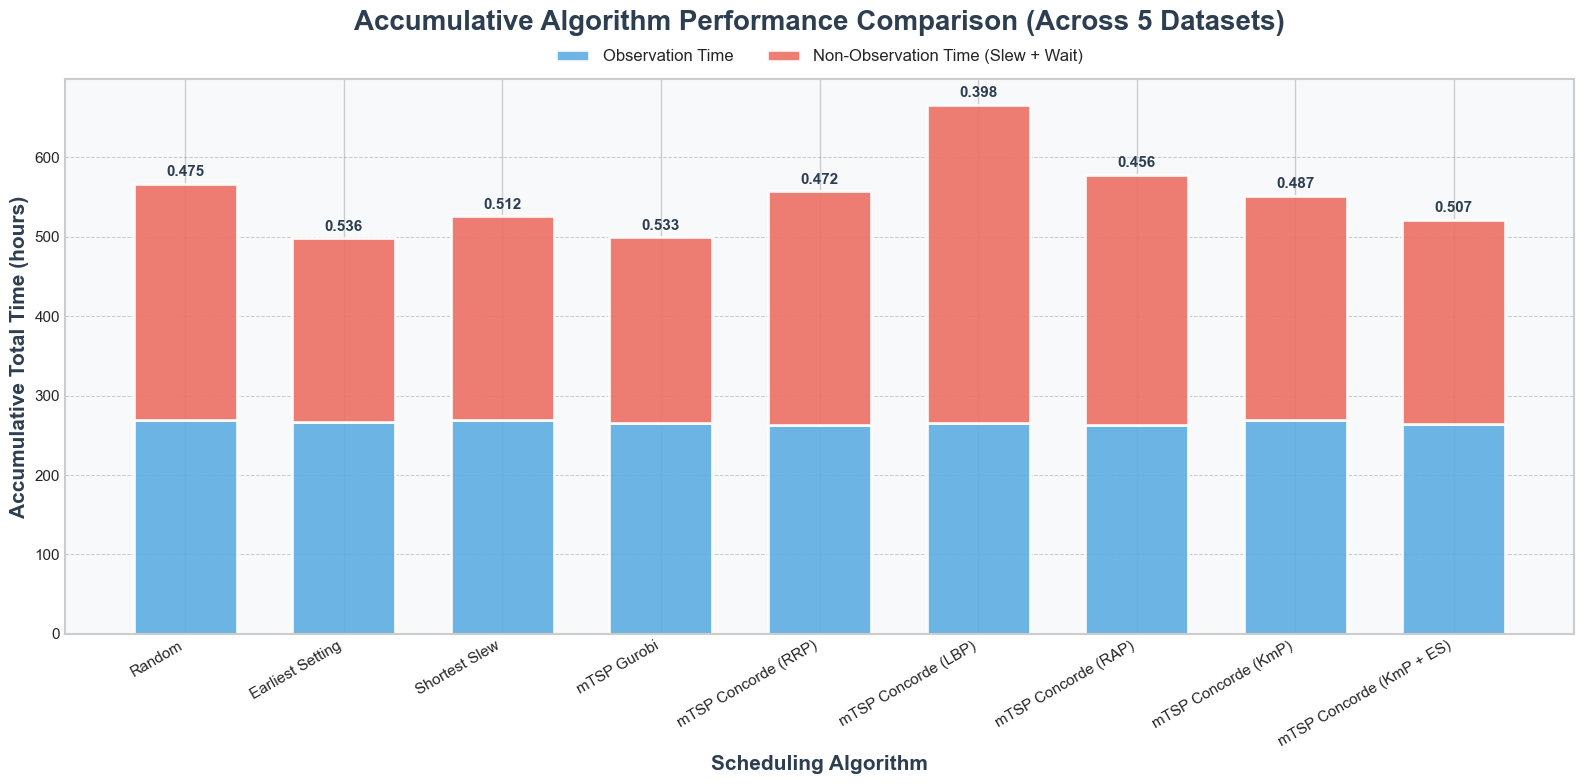

In [31]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Enhanced Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'sans-serif'

# Datasets
datasets = ['dataset1/', 'dataset2/', 'dataset3/', 'dataset4/', 'dataset5/']

# Algorithm folder mappings (8 telescopes only)
folders_8tel = [
    'EarliestSetting8tele',
    'Random8tele',
    'ShortestSlew8tele',
    'tsp8',
    'tspcRoundRobin8',
    'tspcLoadBal8',
    'tspcKmean8',
    'tspcRightAsc8',
    'tspcKMeanEarlySetting8'
]

folder_name_map = {
    "EarliestSetting8tele": "Earliest Setting",
    "Random8tele": "Random",
    "ShortestSlew8tele": "Shortest Slew",
    "tsp8": "mTSP Gurobi",
    "tspcRoundRobin8": "mTSP Concorde (RRP)",
    "tspcLoadBal8": "mTSP Concorde (LBP)",
    "tspcKmean8": "mTSP Concorde (KmP)",
    "tspcRightAsc8": "mTSP Concorde (RAP)",
    "tspcKMeanEarlySetting8": "mTSP Concorde (KmP + ES)"
}

# Data Processing: Accumulate Total Duration across all datasets
accumulated_stats_list = []

for dataset in datasets:
    dataset_name = os.path.basename(os.path.normpath(dataset)) or dataset.strip('/')
    
    for folder in folders_8tel:
        folder_path = os.path.join(dataset, folder)
        csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
        
        if len(csv_files) == 0:
            continue
            
        raw_folder_name = os.path.basename(os.path.normpath(folder))
        folder_name = folder_name_map.get(raw_folder_name, raw_folder_name)
        
        for file in csv_files:
            try:
                df = pd.read_csv(file, header=4)
                df.columns = df.columns.str.strip()
                df['No'] = pd.to_numeric(df['No'], errors='coerce')
                df['Wait time'] = pd.to_numeric(df['Wait time'], errors='coerce')
                
                total_duration = df['No'].sum() / 8
                observation_time = df['Wait time'].sum() / 8
                
                accumulated_stats_list.append({
                    'Dataset': dataset_name,
                    'Algorithm': folder_name,
                    'Total Duration': total_duration,
                    'Observation Time': observation_time
                })
            except Exception as e:
                print(f"Error processing {file}: {e}")

# Create DataFrame with accumulated statistics
accumulated_df = pd.DataFrame(accumulated_stats_list)

# Aggregate statistics across all datasets
accumulated_grouped = accumulated_df.groupby('Algorithm').agg({
    'Total Duration': 'sum',
    'Observation Time': 'sum'
}).reset_index()

# Calculate Non-Observation Time
accumulated_grouped['Non-Observation Time'] = accumulated_grouped['Total Duration'] - accumulated_grouped['Observation Time']

# Sort by desired order
desired_order = [
    "Random",
    "Earliest Setting",
    "Shortest Slew",
    "mTSP Gurobi",
    "mTSP Concorde (RRP)",
    "mTSP Concorde (LBP)",
    "mTSP Concorde (RAP)",
    "mTSP Concorde (KmP)",
    "mTSP Concorde (KmP + ES)"
]

accumulated_grouped['Algorithm'] = pd.Categorical(accumulated_grouped['Algorithm'], categories=desired_order, ordered=True)
accumulated_grouped = accumulated_grouped.sort_values('Algorithm')

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8), dpi=100)
x = np.arange(len(accumulated_grouped))
bar_width = 0.65

# Stacked bars for Total Duration and Observation Time
bars1 = ax.bar(x, accumulated_grouped['Observation Time'], 
               label='Observation Time', 
               color='#5DADE2', 
               edgecolor='white', 
               linewidth=2, 
               width=bar_width,
               alpha=0.9)

bars2 = ax.bar(x, accumulated_grouped['Non-Observation Time'], 
               bottom=accumulated_grouped['Observation Time'],
               label='Non-Observation Time (Slew + Wait)', 
               color='#EC7063', 
               edgecolor='white', 
               linewidth=2, 
               width=bar_width,
               alpha=0.9)

# Observation efficiency ratios
observation_ratio = accumulated_grouped['Observation Time'] / accumulated_grouped['Total Duration']
for i, (obs, total, ratio) in enumerate(zip(accumulated_grouped['Observation Time'], 
                                              accumulated_grouped['Total Duration'],
                                              observation_ratio)):
    # Adjust text position to center over the bars
    ax.text(i, total + 0.012 * total,  # Adjusted x position to be 'i' (centered)
            f"{ratio:.3f}",
            ha='center', va='bottom',  # Horizontal alignment to 'center'
            fontsize=11, 
            weight='bold',
            color='#2C3E50')

# Styling
ax.set_title(f"Accumulative Algorithm Performance Comparison (Across 5 Datasets)", 
             fontsize=20, weight='bold', pad=35, color='#2C3E50')
ax.set_ylabel("Accumulative Total Time (hours)", fontsize=15, weight='bold', color='#2C3E50')
ax.set_xlabel("Scheduling Algorithm", fontsize=15, weight='bold', color='#2C3E50')
ax.set_xticks(x)
ax.set_xticklabels(accumulated_grouped['Algorithm'], fontsize=11, rotation=30, ha='right')
ax.tick_params(axis='both', which='major', labelsize=11)

# Grid
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.4, color='gray')
ax.set_axisbelow(True)

# Legend
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),  # Position below title
    ncol=2,                      # 2 items in one row
    fontsize=12,
    framealpha=0.95,
    edgecolor='gray',
    fancybox=True,
    shadow=True
)

# Add subtle border
for spine in ax.spines.values():
    spine.set_edgecolor('#CCCCCC')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()
